# VDP grid overlay on the Sorcha sky map

Three options for drawing the antisun-relative grid (29 lon × 23 lat = 667 cells) on the two-year Sorcha equatorial density map. Outputs in `Figures/`.

In [16]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import SkyCoord, BarycentricMeanEcliptic, ICRS
import astropy.units as u
%matplotlib inline

DROP_NEO = True   # NEOs are oversampled in this sample; drop for a faithful footprint

df = pd.read_parquet("outputs/phase2/sorcha_comparison_v5_masked.parquet",
     columns=["mean_ra","mean_dec","ecl_lon","ecl_lat","mjd0_tai","population"])

# ---- antisun-relative grid (Section 4: 29 lon x 23 lat) ----
GLON = np.arange(-140, 141, 10)                                  # 29 longitude centres
_lat = np.array([0,1,2,3,4,5,8,12,18,25,35,50])
GLAT = np.sort(np.concatenate([-_lat[1:], _lat]))               # 23 latitude centres
def _edges(c):
    c = np.sort(c); m = (c[:-1]+c[1:])/2
    return np.concatenate([[2*c[0]-m[0]], m, [2*c[-1]-m[-1]]])
LONE, LATE = _edges(GLON), _edges(GLAT)                          # cell boundaries

# ---- antisun longitude and Delta-lambda_sun per tracklet ----
T       = (df.mjd0_tai.values + 2400000.5) - 2451545.0
lam_sun = (280.46 + 0.9856474*T) % 360.0
anti    = (lam_sun + 180.0) % 360.0
dlon    = ((df.ecl_lon.values - anti + 180) % 360) - 180         # antisun-relative lon
beta    = df.ecl_lat.values
print(f"{len(df):,} tracklets | grid {len(GLON)}x{len(GLAT)} = {len(GLON)*len(GLAT)} cells"
      f" | dlon in [{dlon.min():.0f}, {dlon.max():.0f}] deg")


707,670 tracklets | grid 29x23 = 667 cells | dlon in [-140, 140] deg


## Option A — antisun-relative frame (grid is native, rectangular)

In [ ]:
sel = np.abs(dlon) <= 145
xe = np.arange(-145, 146, 2.5); ye = np.arange(-55, 55.1, 2.5)
Hh,_,_ = np.histogram2d(dlon[sel], beta[sel], bins=[xe, ye])
area = np.diff(xe)[:,None] * (np.sin(np.radians(ye[1:]))-np.sin(np.radians(ye[:-1])))[None,:]*(180/np.pi)
dens = Hh / area

fig, ax = plt.subplots(figsize=(12, 5.5))
pc = ax.pcolormesh(xe, ye, np.log10(dens.T + 1e-6), cmap="magma", shading="auto", vmin=0)
for x in LONE:  ax.axvline(x, color="deepskyblue", lw=0.5, alpha=0.6)
for yv in LATE: ax.axhline(yv, color="deepskyblue", lw=0.5, alpha=0.6)
ax.plot(np.repeat(GLON, len(GLAT)), np.tile(GLAT, len(GLON)), ".", color="cyan", ms=2)
ax.axvspan(-150,-140, color="0.3", alpha=.4); ax.axvspan(140,150, color="0.3", alpha=.4)
ax.set_xlim(-150,150); ax.set_ylim(-55,55)
ax.set_xlabel(r"$\Delta\lambda_\odot$  (deg, antisun-relative)"); ax.set_ylabel(r"$\beta$  (deg)")
ax.set_title("VDP grid in its own antisun-relative frame")
fig.colorbar(pc, label=r"$\log_{10}$ tracklets per deg$^2$")
fig.savefig("Figures/sorcha_grid_overlay_A_antisun.png", dpi=200, bbox_inches="tight")
plt.show()

## Options B & C — equatorial sky map

In [ ]:
def ecl2radec(lon, lat):
    sc = SkyCoord(lon=np.atleast_1d(lon)*u.deg, lat=np.atleast_1d(lat)*u.deg,
                  frame=BarycentricMeanEcliptic).transform_to(ICRS())
    return sc.ra.deg, sc.dec.deg

def curve(ra, dec, **kw):
    """Draw a RA/Dec polyline on the current projview, breaking at the RA=180 seam."""
    ra180 = ((np.asarray(ra)+180) % 360) - 180
    o = np.argsort(ra180); ra180, dec = ra180[o], np.asarray(dec)[o]
    brk = np.where(np.abs(np.diff(ra180)) > 180)[0]
    ra180 = np.insert(ra180, brk+1, np.nan); dec = np.insert(dec, brk+1, np.nan)
    hp.newprojplot(theta=np.radians(90-dec), phi=np.radians(ra180), **kw)

NSIDE = 64; npix = hp.nside2npix(NSIDE); pa = hp.nside2pixarea(NSIDE, degrees=True)
mask = (df.population.values != "NEO") if DROP_NEO else np.ones(len(df), bool)
cnt = np.bincount(hp.ang2pix(NSIDE, df.mean_ra.values[mask], df.mean_dec.values[mask], lonlat=True),
                  minlength=npix).astype(float)
dmap = hp.smoothing(np.nan_to_num(cnt/pa), fwhm=np.radians(1.5)); dmap[dmap < 0] = 0
dmap[cnt == 0] = np.nan
VMIN = max(np.nanpercentile(dmap, 2), 1.0); VMAX = np.nanpercentile(dmap, 99.5)

def curve_in_footprint(ra, dec, **kw):
    """Draw a grid line clipped to the survey footprint.
    Does NOT re-sort by RA (unlike curve()) so parametric order is preserved —
    needed for longitude lines where RA is non-monotonic with ecliptic latitude."""
    ra_a = np.asarray(ra, float).copy()
    dec_a = np.asarray(dec, float).copy()
    pix = hp.ang2pix(NSIDE, ra_a, dec_a, lonlat=True)
    out = np.isnan(dmap[pix]) | (dmap[pix] < 1.0)
    ra_a[out] = np.nan; dec_a[out] = np.nan
    ra180 = ((ra_a + 180) % 360) - 180
    d = np.diff(ra180)
    brk = np.where((np.abs(d) > 180) | np.isnan(d))[0]
    ra180 = np.insert(ra180, brk+1, np.nan)
    dec_a = np.insert(dec_a, brk+1, np.nan)
    hp.newprojplot(theta=np.radians(90-dec_a), phi=np.radians(ra180), **kw)

# reference epoch for the snapshot: 2026 May 9 = MJD 61169
mjd_ref  = 61169.0
T0       = (mjd_ref + 2400000.5) - 2451545.0
ANTI_REF = ((280.46 + 0.9856474*T0) % 360 + 180) % 360
print(f"reference epoch MJD {mjd_ref:.0f}  ->  antisun lon {ANTI_REF:.1f} deg")

def basemap(title):
    plt.figure(figsize=(11, 6))
    hp.projview(dmap, coord=["C"], projection_type="mollweide", flip="astro", cmap="magma",
        norm="log", min=VMIN, max=VMAX, graticule=True, graticule_labels=True,
        xlabel="Right Ascension", ylabel="Declination", unit="tracklets per square degree",
        cb_orientation="horizontal", title=title, badcolor="white", bgcolor="white",
        xtick_label_color="0.3", ytick_label_color="0.3")

### Option B — grid snapshot at the reference epoch

In [ ]:
basemap("B: VDP grid snapshot at reference epoch")
for dl in LONE:
    if abs(dl) > 140: continue
    bb = np.linspace(-50, 50, 80)
    curve_in_footprint(*ecl2radec((dl+ANTI_REF)*np.ones_like(bb), bb), color="deepskyblue", lw=0.6)
for bv in LATE:
    ll = np.linspace(-140, 140, 200)
    curve_in_footprint(*ecl2radec(ll+ANTI_REF, bv*np.ones_like(ll)), color="deepskyblue", lw=0.6)
plt.savefig("Figures/sorcha_grid_overlay_B_snapshot.png", dpi=200, bbox_inches="tight")
plt.show()

### Option C — ecliptic-latitude bands only (epoch-stable)

<Figure size 1100x600 with 0 Axes>

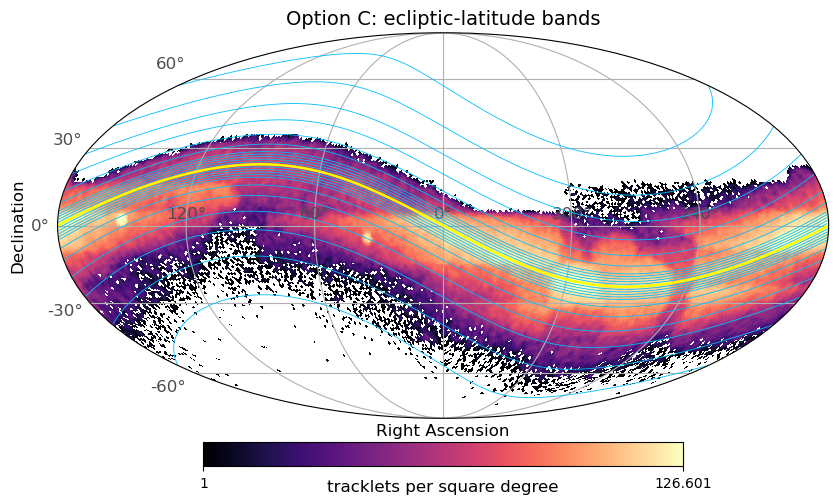

In [20]:
basemap("Option C: ecliptic-latitude bands")
for bv in GLAT:                                    # full-sky constant-beta lines
    ll = np.linspace(0, 360, 400)
    curve(*ecl2radec(ll, bv*np.ones_like(ll)),
          color=("yellow" if bv == 0 else "deepskyblue"), lw=(1.8 if bv == 0 else 0.6))
plt.savefig("Figures/sorcha_grid_overlay_C_bands.png", dpi=200, bbox_inches="tight")
plt.show()


## Notes

- **A**: native frame, rectangular cells, not a sky map.
- **B**: real sky map + full grid at one epoch (cells curve).
- **C**: real sky map + latitude bands only (epoch-stable).

## Bonus — animated sweep (2-year window)

Option B rendered at 10-day steps. Saved to `Figures/sorcha_grid_sweep.gif`.

In [ ]:
import io
from astropy.time import Time
from PIL import Image
from IPython.display import Image as IPyImage, display

STEP_DAYS  = 10
FRAME_MS   = 120
GIF_PATH   = "Figures/sorcha_grid_sweep.gif"

def _anti(mjd):
    T = (mjd + 2400000.5) - 2451545.0
    return ((280.46 + 0.9856474*T) % 360 + 180) % 360

def _frame(mjd):
    a = _anti(mjd)
    dstr = Time(float(mjd), format="mjd").datetime.strftime("%Y-%m-%d")
    hp.projview(dmap, coord=["C"], projection_type="mollweide", flip="astro", cmap="magma",
        norm="log", min=VMIN, max=VMAX, graticule=True, graticule_labels=True,
        xlabel="Right Ascension", ylabel="Declination", unit="tracklets per square degree",
        cb_orientation="horizontal", badcolor="white", bgcolor="white",
        title=f"VDP grid sweep   |   {dstr}   (antisun $\\lambda$={a:.0f}$^\\circ$)")
    for dl in LONE:
        if abs(dl) > 140: continue
        bb = np.linspace(-50, 50, 60)
        curve_in_footprint(*ecl2radec((dl+a)*np.ones_like(bb), bb), color="deepskyblue", lw=0.6)
    for bv in LATE:
        ll = np.linspace(-140, 140, 160)
        curve_in_footprint(*ecl2radec(ll+a, bv*np.ones_like(ll)), color="deepskyblue", lw=0.6)
    aa = np.linspace(-50, 50, 40)
    curve_in_footprint(*ecl2radec(a*np.ones_like(aa), aa), color="yellow", lw=1.4)
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=80, bbox_inches="tight", facecolor="white")
    plt.close("all"); buf.seek(0)
    return Image.open(buf).convert("RGB")

mjds = np.arange(df.mjd0_tai.min(), df.mjd0_tai.max(), STEP_DAYS)
print(f"rendering {len(mjds)} frames ({STEP_DAYS}-day spacing) ...")
frames = [_frame(m) for m in mjds]
w = min(f.width for f in frames); h = min(f.height for f in frames)
frames = [f.resize((w, h)) for f in frames]
frames[0].save(GIF_PATH, save_all=True, append_images=frames[1:],
               duration=FRAME_MS, loop=0, optimize=True)
print(f"saved {GIF_PATH}  ({len(frames)} frames, {w}x{h})")
display(IPyImage(filename=GIF_PATH))